# Install Dependencies and Import

In [ ]:
# Install Dependencies
%pip install -q --upgrade numerapi numerai-tools

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import json
import pickle
from datetime import timedelta
import time

from numerapi import NumerAPI
from numerai_tools.scoring import numerai_corr, correlation_contribution, neutralize

import warnings
warnings.filterwarnings('ignore')

%matplotlib inline

# Functions

In [ ]:
# Общая информация о датафрейме
def describe_df(df: pd.DataFrame):

    n_rows, n_cols = df.shape
    missing_total = df.isnull().sum().sum()
    min_era = df['era'].min()
    max_era = df['era'].max()
    total_eras = df['era'].nunique()

    print(f"Shape: {n_rows} × {n_cols}")
    print(f"Miss: {missing_total}")
    print(f"Eras: {min_era}-{max_era} ({total_eras})")

In [ ]:
# def analyze_missing(train, feature_set, plot=True):

#     # === Missing by Era ===
#     missing_eras = train.groupby('era')[feature_set].apply(lambda x: (x == 2).all(axis=0))
#     missing_eras = missing_eras.reset_index()
#     missing_eras['miss_count'] = missing_eras[feature_set].sum(axis=1)

#     eras_with_missing = missing_eras[missing_eras['miss_count'] > 0]
    
#     last_missing_era = eras_with_missing['era'].max()
#     all_eras_sorted = sorted(train['era'].unique())
    
#     cutoff_idx = all_eras_sorted.index(last_missing_era)
#     cutoff_era = all_eras_sorted[cutoff_idx + 1]  # первая "чистая" эра

#     # === Missing by Features ===
#     missing_features = missing_eras[feature_set].sum(axis=0)
#     missing_features = pd.DataFrame(missing_features, columns=['miss_count'])
#     missing_features["%"] = missing_features['miss_count'] / len(missing_eras) * 100
#     top_missing_features = missing_features.sort_values('miss_count', ascending=False).head(50)

#     if plot:
#         fig, axes = plt.subplots(1, 2, figsize=(14, 4))

#         # Plot Missing by Era
#         axes[0].bar(missing_eras['era'], missing_eras['miss_count'], color='purple', width=1)
#         axes[0].set_title("Missing by Eras (Full Feature Missing)")
#         axes[0].set_xlabel("Eras")
#         axes[0].set_ylabel("Count of Missing Features")
#         axes[0].grid(True, axis='y', alpha=0.3)

#         if cutoff_era:
#             axes[0].axvline(x=last_missing_era, color='red', linestyle='--', label=f'Cutoff → {cutoff_era}')
#             axes[0].legend()

#         # Plot Missing by Features
#         axes[1].barh(top_missing_features.index, top_missing_features['miss_count'], color='salmon', height=0.8)
#         axes[1].set_title("Missing by Features (Top 50)")
#         axes[1].set_xlabel("Count of Eras with Full Missing")
#         axes[1].set_ylabel("Features")
#         axes[1].set_yticks(range(len(top_missing_features)))
#         axes[1].set_yticklabels(top_missing_features.index)
#         axes[1].invert_yaxis()
#         axes[1].grid(True, axis='x', alpha=0.3)

#         plt.tight_layout()
#         plt.show()

#     return cutoff_era


# Loading Numerai Datasets  

In [ ]:
# Initialize NumerAPI
napi = NumerAPI()

# Get current active round for Numerai Tournament
current_round = napi.get_current_round()
print("CURRENT ROUND:", current_round)
print('')

# List all available datasets
all_datasets = napi.list_datasets()

# Extract unique data versions
dataset_versions = list(set(d.split('/')[0] for d in all_datasets))
DATA_VERSION = max(dataset_versions)  # Use latest version
print("AVAILABLE DATA VERSIONS:\n", sorted(dataset_versions))
print('')

# List all files from the latest data version
print(f"FILES IN VERSION {DATA_VERSION}:")
current_version_files = [f for f in all_datasets if f.startswith(DATA_VERSION)]
for f in sorted(current_version_files):
    print(f"  {f}")

In [ ]:
napi.download_dataset(f"{DATA_VERSION}/features.json")
napi.download_dataset(f"{DATA_VERSION}/train.parquet")
napi.download_dataset(f"{DATA_VERSION}/validation.parquet")
napi.download_dataset(f"{DATA_VERSION}/meta_model.parquet")

# Feature Metadata  
  
В версии 'v5.2' 18 наборов признаков и 41 таргет.  
- К таргетам вернусь на стадии создания ансамбля.  

**Feature Sets:**
- Общие наборы: 'small', 'medium', 'all'. Включают в себя признаки из разных наборов.
- 'v2_equivalent_features' и 'v3_equivalent_features' - для совместимости со старыми версиями данных. Но признаки из этих наборов есть и в тематических.  
- 'fncv3_features' - специальный набор фичей, созданный для 'feature neutral correlation version 3'.
- Тематические наборы: 'intelligence', 'charisma', 'strength', 'dexterity', 'constitution', 'wisdom', 'agility', 'serenity', 'sunshine', 'rain', 'midnight', 'faith'.   
  
<br>

Оптимальный набор для старта - Medium (780 признаков).  
Сохраняю словарь `medium_dict` для нейтрализации признаков.

In [172]:
# === LOADING METADATA ===
feature_metadata = json.load(open(f"{DATA_VERSION}/features.json"))
feature_sets = feature_metadata["feature_sets"]

grouped_sets = {}
for size_set in ['small', 'medium', 'all']:
        grouped_sets[size_set] = {}
        for k, v in feature_sets.items():
                if k not in ['small', 'medium']:
                    grouped_sets[size_set][k] = list(set(feature_sets[size_set]) & set(feature_sets[k]))

medium_dict = grouped_sets['medium']  # For neutralize features
medium_set = medium_dict['all']  # Set of features - Medium

grouped_sets_df = pd.DataFrame(grouped_sets)
grouped_sets_df = grouped_sets_df.applymap(lambda x: len(x)).sort_values(by='all', ascending=False)
display(grouped_sets_df)

,small,medium,all
all,42,780,2748
v3_equivalent_features,15,400,1000
rain,20,0,666
fncv3_features,8,400,400
faith,0,75,372
constitution,2,134,335
sunshine,5,130,325
v2_equivalent_features,7,304,304
charisma,3,116,290
midnight,0,122,244


# Uploading Datasets

## Train


In [173]:
# Load dataset with medium features
train = pd.read_parquet(f"{DATA_VERSION}/train.parquet", columns=["era", "target"] + medium_set)
train['era'] = train['era'].astype(int)

describe_df(train)
display(train.head(1))

Shape: 2746270 × 782
Miss: 2
Eras: 1-574 (574)


,era,target,feature_crazy_thieving_beanstalk,feature_homier_congestive_queening,feature_rearward_athetoid_genipap,feature_haemostatic_pulpiest_pembroke,feature_cresylic_avestan_garfield,feature_snuffier_unmeriting_mentation,feature_imputable_parsonical_dulciana,feature_mopiest_iterative_hoggin,...,feature_flamboyant_veterinary_expelling,feature_steely_planimetric_supersedure,feature_renounceable_baking_stocker,feature_skimpy_caudate_crenation,feature_unforewarned_jessant_fusilier,feature_altern_packaged_presbyterian,feature_sapid_ungenuine_moper,feature_coreferential_stellar_airport,feature_kyphotic_uncrated_classicality,feature_laryngitic_pollinic_marination
id,,,,,,,,,,,,,,,,,,,,,
n0007b5abb0c3a25,1,0.25,2,1,2,0,2,2,2,2,...,0,2,0,2,2,1,1,1,2,2


In [174]:
# Drop rows where target=NaN
display(train[train.isna().any(axis=1)])
train = train.dropna(subset=['target'])
describe_df(train)

,era,target,feature_crazy_thieving_beanstalk,feature_homier_congestive_queening,feature_rearward_athetoid_genipap,feature_haemostatic_pulpiest_pembroke,feature_cresylic_avestan_garfield,feature_snuffier_unmeriting_mentation,feature_imputable_parsonical_dulciana,feature_mopiest_iterative_hoggin,...,feature_flamboyant_veterinary_expelling,feature_steely_planimetric_supersedure,feature_renounceable_baking_stocker,feature_skimpy_caudate_crenation,feature_unforewarned_jessant_fusilier,feature_altern_packaged_presbyterian,feature_sapid_ungenuine_moper,feature_coreferential_stellar_airport,feature_kyphotic_uncrated_classicality,feature_laryngitic_pollinic_marination
id,,,,,,,,,,,,,,,,,,,,,
n1b7cb7d2e61e62f,1,NaN,2,3,2,1,2,2,3,2,...,1,2,4,0,0,4,2,2,2,2
n1bbddbf04570ab8,1,NaN,2,4,2,2,2,2,2,2,...,4,2,1,3,3,1,0,0,2,2


Shape: 2746268 × 782
Miss: 0
Eras: 1-574 (574)


### Target  
  
`Target` (float32) распределён по 5 неравным бинам: 0, 0.25, 0.5, 0.75, 1.0  
Это распределение относится как ко всему датасету, так и для каждой эры отдельно.



In [ ]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 3))

train['target'].plot(kind='hist', title='Target', xlabel='Value', density=True, bins=50, ax=ax1)
train.groupby('era')['target'].value_counts(normalize=True).unstack(fill_value=0).plot(ax=ax2)

ax2.set_title("Target Distribution by Era")
plt.show()

### Analysis of Missing Values

In [175]:
def analyze_missing(train: pd.DataFrame, feature_set: list, plot=True):

    # === Missing by Era ===
    missing_eras = train.groupby('era')[feature_set].apply(lambda x: (x == 2).all(axis=0))
    missing_eras = missing_eras.reset_index()
    missing_eras['miss_count'] = missing_eras[feature_set].sum(axis=1)

    eras_with_missing = missing_eras[missing_eras['miss_count'] > 0]
    
    last_missing_era = eras_with_missing['era'].max()
    all_eras_sorted = sorted(train['era'].unique())
    
    cutoff_idx = all_eras_sorted.index(last_missing_era)
    cutoff_era = all_eras_sorted[cutoff_idx + 1]  # первая "чистая" эра

    # === Missing by Features ===
    top_k = 10
    missing_features = missing_eras[feature_set].sum(axis=0)
    missing_features = pd.DataFrame(missing_features, columns=['miss_count'])
    missing_features["%"] = missing_features['miss_count'] / len(missing_eras) * 100
    top_missing_features = missing_features.sort_values('miss_count', ascending=False).head(top_k)

    if plot:
        fig, axes = plt.subplots(1, 2, figsize=(14, 4))

        # Plot Missing by Era
        axes[0].bar(missing_eras['era'], missing_eras['miss_count'], color='purple', width=1)
        axes[0].set_title("Missing by Eras")
        axes[0].set_xlabel("Eras")
        axes[0].set_ylabel("Missing")
        axes[0].grid(True, alpha=0.3)

        if cutoff_era:
            axes[0].axvline(x=last_missing_era, color='red', linestyle='--', label=f'First era without missing: {cutoff_era}')
            axes[0].legend()

        # Plot Missing by Features
        axes[1].barh(top_missing_features.index, top_missing_features['miss_count'], color='salmon', height=0.8)
        axes[1].set_title(f"Top-{top_k} Missing by Features")
        axes[1].set_xlabel("Count of Eras with Full Missing")
        axes[1].set_ylabel("Features")
        # axes[1].set_yticks([])  # Убираем ВСЕ метки на оси Y
        axes[1].set_yticks(range(len(top_missing_features)))
        axes[1].set_yticklabels(top_missing_features.index)
        axes[1].invert_yaxis()
        axes[1].grid(True, axis='x', alpha=0.3)

        plt.tight_layout()
        plt.show()

    return cutoff_era, missing_features


In [177]:
def get_missing_features_in_era(df: pd.DataFrame, era: int, feature_set: list):

    era_data = df[df['era'] == era]
    if era_data.empty:
        print(f"❌ Эра {era} не найдена в данных.")
        return []
    
    # Проверяем: все ли значения признака == 2
    missing_mask = (era_data[feature_set] == 2).all(axis=0)  # по столбцам
    missing_features = missing_mask[missing_mask].index.tolist()
    
    return missing_features

# test = get_missing_features_in_era(train, 369, medium_features_clean)


# Удалить первые 10 признаков

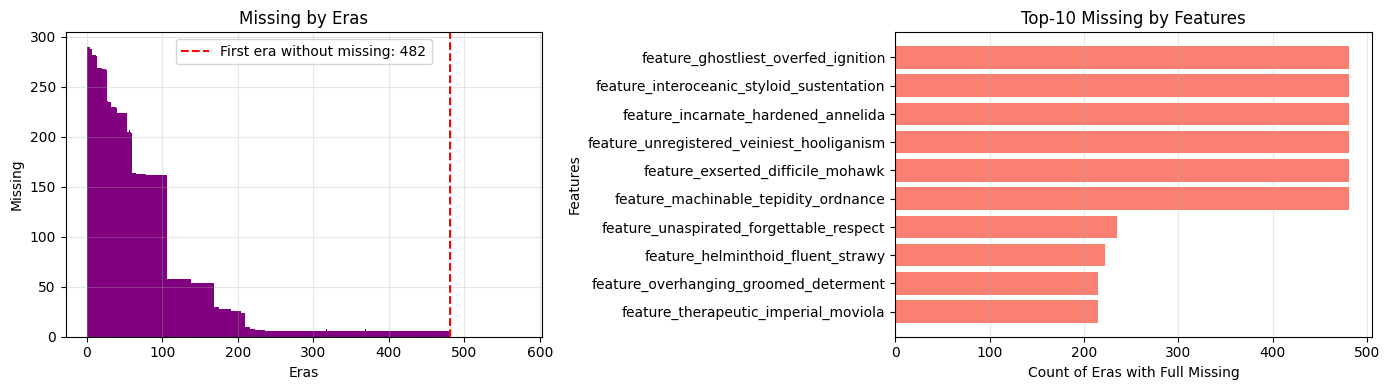

,miss_count,%
feature_ghostliest_overfed_ignition,481,83.797909
feature_interoceanic_styloid_sustentation,481,83.797909
feature_incarnate_hardened_annelida,481,83.797909
feature_unregistered_veiniest_hooliganism,481,83.797909
feature_exserted_difficile_mohawk,481,83.797909
feature_machinable_tepidity_ordnance,481,83.797909
feature_unaspirated_forgettable_respect,235,40.940767
feature_helminthoid_fluent_strawy,222,38.675958
feature_overhanging_groomed_determent,215,37.456446
feature_therapeutic_imperial_moviola,215,37.456446


In [178]:
# Step 1
cutoff_era, missing_features = analyze_missing(train, medium_set, plot=True)
display(missing_features.sort_values('%', ascending=False).head(10))

In [179]:
# Удаляем фичи
excluded_features_1 = set(missing_features[missing_features['%'] > 80].index)
# dict_medium_clean = {key: set(value) - excluded_features_1 for key, value in medium_dict.items()}
medium_features_clean = set(medium_set) - excluded_features_1
print(f"Step 1 — Remaining Features: {len(medium_features_clean)}/{len(medium_set)} (removed: {len(excluded_features_1)})")

Step 1 — Remaining Features: 774/780 (removed: 6)


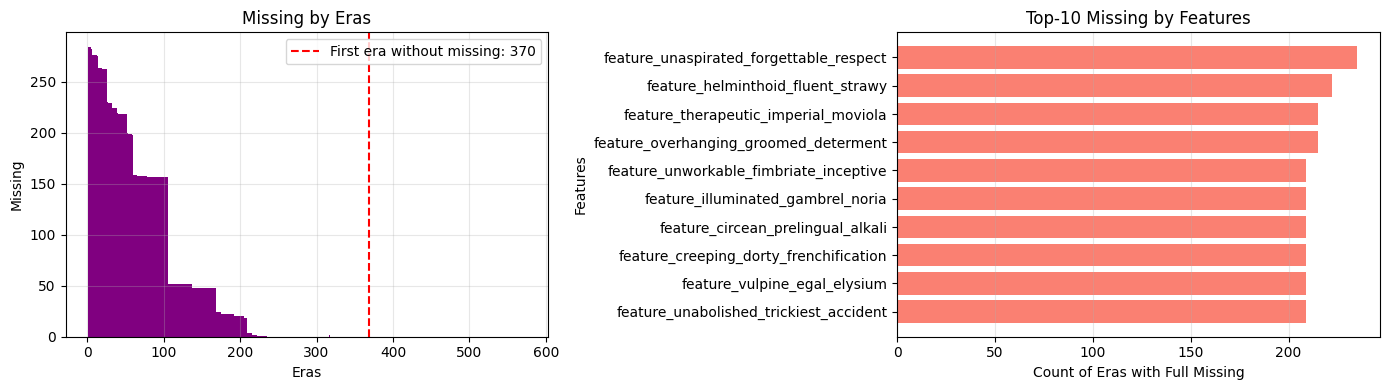

In [180]:
cutoff_era, missing_features = analyze_missing(train, list(medium_features_clean), plot=True)
# display(missing_features.sort_values('%', ascending=False).head(10))

In [181]:
def auto_cutoff_and_clean(train, feature_set, medium_dict, max_missing_per_era=2, min_era='1'):

    current_features = set(feature_set)
    current_dict = {k: set(v) for k, v in medium_dict.items()}
    all_eras = sorted(train['era'].unique())
    
    while True:
        # Анализируем пропуски
        cutoff_era, missing_features = analyze_missing(train[train['era'].isin(all_eras)], list(current_features), plot=False)
        print(f"Current cutoff_era: {cutoff_era}")
        
        # Определяем индекс cutoff_era
        try:
            cutoff_idx = all_eras.index(cutoff_era)
        except ValueError:
            print("cutoff_era not in era list. Stopping.")
            break
            
        if cutoff_idx == 0:
            print("Достигнута первая эра.")
            break
            
        prev_era = all_eras[cutoff_idx - 1]
        print(f"Проверка предыдущей эры: {prev_era}")
        
        # Получаем фичи, полностью пропущенные в prev_era
        missing_in_prev = set(get_missing_features_in_era(train, prev_era, list(current_features)))
        
        if len(missing_in_prev) == 0:
            print(f"Эра {prev_era} чиста — можно начинать с {prev_era}")
            cutoff_era = prev_era
            break
        
        if len(missing_in_prev) <= max_missing_per_era:
            print(f"Удаляем {len(missing_in_prev)} фич из эры {prev_era}: {missing_in_prev}")
            current_features -= missing_in_prev
            # Обновляем словарь групп
            current_dict = {k: v - missing_in_prev for k, v in current_dict.items()}
        else:
            print(f"Эра {prev_era} имеет {len(missing_in_prev)} пропущенных фич — слишком много, останавливаемся.")
            break
        
        # Защита от ухода слишком далеко
        if prev_era <= min_era:
            print(f"Достигнута минимальная разрешённая эра: {min_era}")
            break
    
    print(f"Финальный cutoff_era: {cutoff_era}")
    print(f"Осталось фич: {len(current_features)}")
    
    return cutoff_era, list(current_features), current_dict


In [182]:
# Запуск автоматической очистки
final_cutoff, medium_features_clean, dict_medium_clean = auto_cutoff_and_clean(
    train, 
    medium_set, 
    medium_dict,
    max_missing_per_era=2,
    min_era='1'
)


Current cutoff_era: 482
Проверка предыдущей эры: 481
Эра 481 имеет 6 пропущенных фич — слишком много, останавливаемся.
Финальный cutoff_era: 482
Осталось фич: 780


In [ ]:
excluded_features_2 = set(get_missing_features_in_era(train, (cutoff_era-1), list(medium_features_clean)))
if len(excluded_features_2) <= 2:
    medium_features_clean = set(medium_features_clean) - excluded_features_2
    cutoff_era, missing_features = analyze_missing(train, list(medium_features_clean), plot=False)
    print(cutoff_era)
    print(f"Remaining Features: {len(medium_features_clean)}/{len(medium_set)}")



236
Remaining Features: 772/780)


In [ ]:
test = set(medium_features_clean) - excluded_features_2
len(test)

In [ ]:
excluded_features_2 = set(get_missing_features_in_era(train, (cutoff_era-1), medium_features_clean))
dict_medium_clean = {key: set(value) - excluded_features_2 for key, value in dict_medium_clean.items()}  # обновляем
medium_features_clean = list(dict_medium_clean['all'])

print(f"Step 2 — Remaining Features: {len(medium_features_clean)}/{len(medium_set)} (total removed: {len(excluded_features_1) + len(excluded_features_2)})")

In [ ]:
# Step 3
cutoff_era, missing_features = analyze_missing(train, medium_features_clean, plot=True)
display(missing_features.sort_values('%', ascending=False).head(10))

In [ ]:
excluded_features_3 = set(get_missing_features_in_era(train, (cutoff_era-1), medium_features_clean))
dict_medium_clean = {key: set(value) - excluded_features_3 for key, value in dict_medium_clean.items()}  # обновляем
medium_features_clean = list(dict_medium_clean['all'])

print(f"Step 3 — Remaining Features: {len(medium_features_clean)}/{len(medium_set)} (total removed: {len(excluded_features_1) + len(excluded_features_2) + len(excluded_features_3)})")

In [ ]:
# Удаляем дополнительные фичи
excluded_features_2 = set(missing_features[missing_features['%'] > 37].index)
dict_medium_clean = {key: set(value) - excluded_features_2 for key, value in dict_medium_clean.items()}  # обновляем
medium_features_clean = list(dict_medium_clean['all'])

print(f"Step 2 — Remaining Features: {len(medium_features_clean)}/{len(medium_set)} (total removed: {len(excluded_features_1) + len(excluded_features_2)})")

In [ ]:
# Проверка результата
cutoff_era, missing_features = analyze_missing(train, medium_features_clean, plot=True)
print(f"Final — Features left: {len(medium_features_clean)}")
display(missing_features.sort_values('%', ascending=False).head(10))

In [ ]:
cutoff_era, missing_features = analyze_missing(train, medium_set)
display(missing_features.sort_values('%', ascending=False).head(10))

In [ ]:
# === Removing Features with Missing
excluded_features = set(missing_features[missing_features['%'] > 80].index)

dict_medium_clean = {key: set(value) - excluded_features for key, value in medium_dict.items()}
medium_features_clean = list(dict_medium_clean['all'])
cutoff_era, missing_features = analyze_missing(train, medium_features_clean)

print(f"Remaining Features: {len(dict_medium_clean['all'])}/{len(medium_set)} ({len(excluded_features)})")
display(missing_features.sort_values('%', ascending=False).head(10))

In [ ]:
cutoff_era, missing_features = analyze_missing(train, medium_features_clean)
display(missing_features.sort_values('%', ascending=False).head(10))

In [ ]:
# === Removing Features with Missing
excluded_features = set(missing_features[missing_features['%'] > 37].index)

dict_medium_clean = {key: set(value) - excluded_features for key, value in medium_dict.items()}
medium_features_clean = list(dict_medium_clean['all'])

cutoff_era, missing_features = analyze_missing(train, medium_features_clean)

print(f"Remaining Features: {len(dict_medium_clean['all'])}/{len(medium_set)} ({len(excluded_features)})")
display(missing_features.sort_values('%', ascending=False).head(10))

In [ ]:
len(medium_features_clean)

3 признака с большим количеством пропусков нужно удалить из всех наборов.

In [ ]:
cutoff_era, missing_features = analyze_missing(train, medium_features_clean)

In [ ]:
missing_features.sort_values('%', ascending=False).head(10)

In [ ]:
# Checking After Removing Features
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# === Missing by Era ===
missing_eras = train.groupby('era')[medium_features_clean].apply(lambda x: (x == 2).all(axis=0))
missing_eras = missing_eras.reset_index()
missing_eras['miss_count'] = missing_eras[medium_features_clean].sum(axis=1)

eras_with_missing = missing_eras[missing_eras['miss_count'] > 0]
last_missing_era = eras_with_missing['era'].max()  # Last era with missing

all_eras_sorted = sorted(train['era'].unique())
cutoff_idx = all_eras_sorted.index(last_missing_era)
cutoff_era = all_eras_sorted[cutoff_idx + 1]  # First era without missing

axes[0].grid()
axes[0].bar(missing_eras['era'], missing_eras['miss_count'], color='purple', width=1)
axes[0].set_title("Missing by Eras")
axes[0].set_xlabel("Eras")
axes[0].set_ylabel("Count")
axes[0].grid(True, alpha=0.3)
if cutoff_era:
    axes[0].axvline(x=last_missing_era, color='purple', linestyle='--', label=f'First era without missing: {cutoff_era}')
    axes[0].legend()


# === Missing by Features ===
missing_features = missing_eras[medium_features_clean].sum(axis=0) 
missing_features = pd.DataFrame(missing_features).rename(columns={0: 'miss_count'})
missing_features["%"] = missing_features['miss_count'] / len(missing_eras) * 100
top_missing_features = missing_features.sort_values('miss_count', ascending=False)[:50]

axes[1].barh(top_missing_features.index, top_missing_features['miss_count'], color='salmon', height=0.8)
axes[1].set_title("Missing by Features")
axes[1].set_xlabel("Count of Eras")
axes[1].set_ylabel("Features")
axes[1].set_yticks(range(len(top_missing_features)))
axes[1].set_yticklabels(top_missing_features.index)
axes[1].invert_yaxis()
axes[1].grid(True, axis='x', alpha=0.3)


plt.tight_layout()
plt.show()

Начиная с эры 210 почти нет пропусков.  
Обрезаю Train c `first_clean_era`.  

In [ ]:
first_clean_era = missing_eras[missing_eras['miss_count'] == 0]['era'].min()

train_clean = train[train.era >= cutoff_era][['era', 'target'] + medium_features_clean]

print(f"Строки: {train_clean.shape[0]}")
print(f"Столбцы: {train_clean.shape[1]}")
print(f"Признаки: {len(medium_features_clean)}")
print(f"Эры: {train_clean['era'].min()}-{train_clean['era'].max()} ({train_clean['era'].nunique()})")

## Validation

In [ ]:
# Load dataset
validation = pd.read_parquet(f"{DATA_VERSION}/validation.parquet", columns=["era", "target", "data_type"] + medium_features_clean)
validation['era'] = validation['era'].astype(int)

validation = validation[validation["data_type"] == "validation"]
del validation["data_type"]

describe_df(validation)
display(validation.head(1))

In [ ]:
# # Embargo the first 4 eras
# last_era = int(train_clean["era"].unique()[-1])
# eras_embargo = [era for era in [last_era + i for i in range(1, 5)]]
# validation = validation[~validation["era"].isin(eras_embargo)]

# print(f'Train eras: {train_clean.era.min()}-{train_clean.era.max()} ({train_clean["era"].nunique()})')
# print(f'Validation eras: {validation.era.min()}-{validation.era.max()} ({validation["era"].nunique()})')
# print(f'Eras embargo: {eras_embargo}')

### Meta Model  

Добавлю к 'validation' столбец 'numerai_meta_model' для рассчёта 'MMC.
   
- **MMC (Meta Model Contribution)** — мера того, насколько уникально и добавочно модель улучшает 'Numerai Meta Model'.

In [ ]:
meta_model = pd.read_parquet(f"{DATA_VERSION}/meta_model.parquet")
meta_model['era'] = meta_model['era'].astype(int)

describe_df(meta_model)
meta_model.head(1)

In [ ]:
# Join numerai_meta_model and validation
validation = validation.join(meta_model["numerai_meta_model"], how="left")
validation.rename(columns={"numerai_meta_model": "meta_model"}, inplace=True)

# Сколько строк в каждом датафрейме
print(f"Rows Validation: {len(validation)}")
print(f"Rows MetaModel: {len(meta_model)}")

# Matching ID (indexes)
common_ids = validation.index.intersection(meta_model.index)
print(f"Matching ID: {len(common_ids)}")

# Train / Val

In [ ]:
PURGE = 2 
EMBARGO = 2 

unique_train_eras = sorted(train['era'].unique())
unique_val_eras = sorted(validation['era'].unique())

# Removing the latest `PURGE` eras from Train
purge_eras = [int(x) for x in unique_train_eras[-PURGE:]]
train_clean = train_clean[~train_clean['era'].isin(purge_eras)]

# Skipping the first `EMBARGO` eras from Validation
embargo_eras = [int(x) for x in unique_val_eras[:EMBARGO]]
val_clean = validation[~validation['era'].isin(embargo_eras)]

print(f"Purge: {purge_eras}")
print(f"Embargo: {embargo_eras}")
print(f"Train: {train_clean.shape}")
print(f"Val: {val_clean.shape}")

In [ ]:
summary_data = {
    'Dataset': ['Train', 'Validation'],
    'Rows': [train_clean.shape[0], val_clean.shape[0]],
    'Cols': [train_clean.shape[1], val_clean.shape[1]],
    'Min Era': [train_clean.era.min(), val_clean.era.min()],
    'Max Era': [train_clean.era.max(), val_clean.era.max()],
    # 'Purge/Embargo': [purge_eras, embargo_eras],
    'Purge': [purge_eras, None],
    'Embargo': [None, embargo_eras],
    'N Eras': [train_clean['era'].nunique(), val_clean['era'].nunique()],  
}

summary_df = pd.DataFrame(summary_data).set_index('Dataset')
display(summary_df)

In [ ]:
# === Distribution Rows by Era ===
train_era_count = train_clean.groupby("era").size()
val_era_count = val_clean.groupby("era").size()

combined = pd.concat([train_era_count, val_era_count], axis=1, keys=['Train', 'Validation'])
combined.index = pd.Categorical(combined.index, categories=sorted(combined.index), ordered=True)
combined = combined.sort_index()

ax = combined.plot(
    kind='line',
    figsize=(10, 4),
    title="Rows per Era (Train vs Validation)",
    xlabel="Era",
    ylabel="Number of Rows", alpha=0.8, grid=True
)

ax.legend()
plt.tight_layout()
plt.show()


# Saving Data  

- `train_medium.parquet` - Train без пропусков с 210 по 574 эры. Всего - 365 эр.
- `validation_medium.parquet` - Validation с 579 по 1190 эры и эмбарго 4 эры (575-578). Всего - 612 эр. Добавлен столбец `numerai_meta_model` с 1133 по 1190 эры.
- `dict_medium_clean.pkl` - Словарь для Medium, сгруппированный по наборам для нейтрализаии.

In [ ]:
train_clean.to_parquet("/content/drive/MyDrive/Colab Notebooks/Step_1/train_medium.parquet")
val_clean.to_parquet("/content/drive/MyDrive/Colab Notebooks/Step_1/val_medium.parquet")

with open("/content/drive/MyDrive/Colab Notebooks/Step_1/grouped_set_medium.pkl", "wb") as f:
    pickle.dump(dict_medium_clean, f)